# P-ML4 — Regime-Specific LightGBM Models

**Motivation (F9):** P-ML3 showed that blunt regime interventions work:
- Exp-B (flip in bull): +33.2% equity, Sharpe +0.482
- Exp-C (skip bull): +8.8% equity, Sharpe +0.280

**Hypothesis:** Separate models for bull and non-bull regimes should outperform both,
because each model can learn the *correct* relationship for its regime:
trend-continuation in bull, mean-reversion in bear/ranging.

**Architecture:** `RegimeEnsemble` trains two `LGBMForecaster` instances per fold:
- **Non-bull model** — trained on bear + ranging bars (always feasible)
- **Bull model** — trained on bull bars only if ≥ `MIN_BULL_BARS` exist;
  otherwise falls back to sign-flipping the non-bull model (P-ML3 Exp-B)


## §1 — Config

In [1]:
import sys
from pathlib import Path

repo_root = Path("__file__").resolve().parent.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams.update({
    "figure.dpi":        120,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.size":         9,
})

SINCE         = "2022-01-01"
UNTIL         = "2025-01-01"
HORIZON       = 1
N_SPLITS      = 5
TRAIN_FRAC    = 0.6
PURGE         = 1
LONG_MA       = 200
ADX_THRESH    = 25.0
MIN_BULL_BARS = 30   # minimum bull training bars to fit a dedicated bull model

FEATURES = [
    "bar_ret", "bb_zscore", "rsi", "macd_hist_norm", "atr_pct",
    "bb_width", "upper_wick", "lower_wick", "hl_range",
    "vol_log_chg", "di_diff", "adx",
]

print(f"Dataset:       {SINCE} → {UNTIL} | 1d | horizon={HORIZON}")
print(f"Walk-forward:  {N_SPLITS} folds, train_frac={TRAIN_FRAC}, purge={PURGE}")
print(f"Regime:        SMA({LONG_MA}) + ADX>{ADX_THRESH}")
print(f"MIN_BULL_BARS: {MIN_BULL_BARS}")

Dataset:       2022-01-01 → 2025-01-01 | 1d | horizon=1
Walk-forward:  5 folds, train_frac=0.6, purge=1
Regime:        SMA(200) + ADX>25.0
MIN_BULL_BARS: 30


## §2 — Data + Regime Labeling

In [2]:
from data.fetch import fetch_ohlcv
from ml.features import build_feature_matrix
from ml.labels import forward_return
from ml.regime import RegimeClassifier
from ml.validation import purged_wf_splits

df    = fetch_ohlcv(timeframe="1d", since=SINCE, until=UNTIL)
feats = build_feature_matrix(df)
label = forward_return(df, horizon=HORIZON)
comb  = pd.concat([feats, label], axis=1).dropna()
X_all = comb[feats.columns]
y_all = comb[label.name]
X     = X_all[FEATURES]

rc  = RegimeClassifier(long_ma=LONG_MA, adx_thresh=ADX_THRESH)
reg = rc.transform(df).reindex(X.index)
reg["regime"] = reg["regime"].fillna("ranging")
for col in ["regime_bull", "regime_bear", "regime_ranging"]:
    reg[col] = reg[col].fillna(0).astype(int)

bar_ret_daily = np.log(df["close"] / df["close"].shift(1)).reindex(X.index)
splits = list(purged_wf_splits(len(X), N_SPLITS, TRAIN_FRAC, purge_bars=PURGE))

print(f"{len(X):,} usable bars | {X.index[0].date()} → {X.index[-1].date()}")
print(f"\nOverall regime: bull={reg['regime_bull'].mean()*100:.1f}%  "
      f"bear={reg['regime_bear'].mean()*100:.1f}%  "
      f"ranging={reg['regime_ranging'].mean()*100:.1f}%")

1,075 usable bars | 2022-01-22 → 2024-12-31

Overall regime: bull=31.9%  bear=17.6%  ranging=50.5%


## §3 — Training-Fold Regime Distribution

The key constraint for P-ML4: does each training fold contain enough bull bars
to fit a dedicated bull model (`MIN_BULL_BARS = 30`)?

Training-fold regime breakdown (MIN_BULL_BARS=30):
Fold   Train period                     bull   bear  ranging   total  bull_model?
------------------------------------------------------------------------------
  1    2022-01-22 → 2022-07-18             0     89       89     178     FALLBACK
  2    2022-04-22 → 2023-01-13             1    120      146     267     FALLBACK
  3    2022-10-18 → 2023-07-11           128     35      104     267          YES
  4    2023-04-15 → 2024-01-06           133     30      104     267          YES
  5    2023-10-11 → 2024-07-03           136      1      130     267          YES


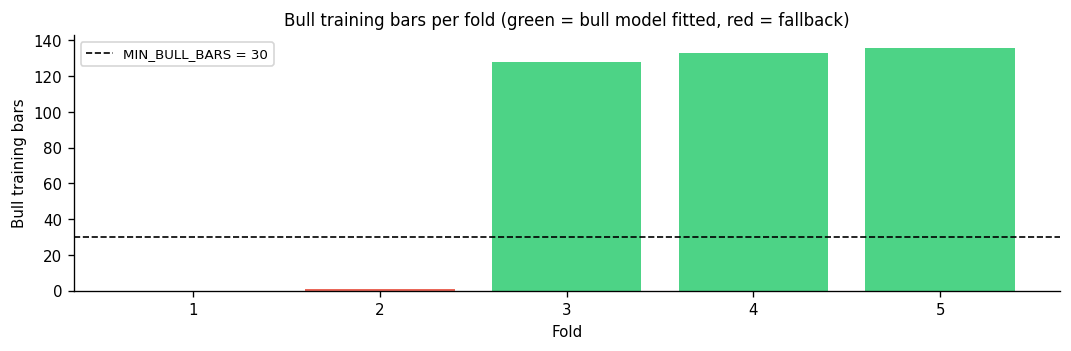

In [3]:
print(f"Training-fold regime breakdown (MIN_BULL_BARS={MIN_BULL_BARS}):")
print(f"{'Fold':<6} {'Train period':<30} {'bull':>6} {'bear':>6} "
      f"{'ranging':>8} {'total':>7} {'bull_model?':>12}")
print("-" * 78)

train_bull_counts = []
for i, (tr, te) in enumerate(splits):
    vc    = reg["regime"].iloc[tr].value_counts()
    n_bull = vc.get("bull", 0)
    has_bull = n_bull >= MIN_BULL_BARS
    train_bull_counts.append(n_bull)
    period = f"{X.index[tr[0]].date()} → {X.index[tr[-1]].date()}"
    print(f"  {i+1:<4} {period:<30} "
          f"{n_bull:>6} {vc.get('bear',0):>6} {vc.get('ranging',0):>8} "
          f"{len(tr):>7} {'YES' if has_bull else 'FALLBACK':>12}")

# Bar chart: bull bars per training fold
fig, ax = plt.subplots(figsize=(9, 3))
colors = ["#2ecc71" if n >= MIN_BULL_BARS else "#e74c3c" for n in train_bull_counts]
ax.bar(range(1, N_SPLITS + 1), train_bull_counts, color=colors, alpha=0.85)
ax.axhline(MIN_BULL_BARS, color="black", linewidth=1.0, linestyle="--",
           label=f"MIN_BULL_BARS = {MIN_BULL_BARS}")
ax.set_xlabel("Fold")
ax.set_ylabel("Bull training bars")
ax.set_title("Bull training bars per fold (green = bull model fitted, red = fallback)",
             fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## §4 — Non-Bull Model: IC on Non-Bull Test Bars

Train `LGBMForecaster` on bear + ranging bars only. Evaluate on non-bull test bars.
Expected: consistent negative IC (mean reversion dominates when not trending up).

In [4]:
from ml.models import LGBMForecaster

nb_fold_results = []   # non-bull model results

for i, (tr, te) in enumerate(splits):
    non_bull_tr = reg["regime"].iloc[tr] != "bull"
    non_bull_te = reg["regime"].iloc[te] != "bull"

    model = LGBMForecaster()
    model.fit(X.iloc[tr][non_bull_tr], y_all.iloc[tr][non_bull_tr])

    # Evaluate only on non-bull test bars
    if non_bull_te.sum() < 2:
        rho, pval, hit = float("nan"), 1.0, float("nan")
    else:
        preds_nb = model.predict(X.iloc[te][non_bull_te])
        actual   = y_all.iloc[te][non_bull_te].values
        rho, pval = stats.spearmanr(preds_nb, actual)
        hit       = (np.sign(preds_nb) == np.sign(actual)).mean()

    nb_fold_results.append({"fold": i+1, "IC": rho, "pval": pval, "hit": hit,
                             "n_train": int(non_bull_tr.sum()),
                             "n_test": int(non_bull_te.sum()), "model": model})
    period = f"{X.index[te[0]].date()} → {X.index[te[-1]].date()}"
    print(f"Fold {i+1} [{period}]  "
          f"train={int(non_bull_tr.sum())}  test_nb={int(non_bull_te.sum())}  "
          f"IC={rho:+.4f}  hit={hit:.3f}")

nb_ics = [r["IC"] for r in nb_fold_results]
print(f"\nNon-bull model: Mean IC={np.nanmean(nb_ics):+.4f}  "
      f"ICIR={np.nanmean(nb_ics)/np.nanstd(nb_ics):.3f}")

Fold 1 [2022-07-20 → 2023-01-14]  train=178  test_nb=177  IC=-0.0662  hit=0.514
Fold 2 [2023-01-15 → 2023-07-12]  train=266  test_nb=52  IC=-0.0168  hit=0.558
Fold 3 [2023-07-13 → 2024-01-07]  train=139  test_nb=94  IC=-0.1311  hit=0.457
Fold 4 [2024-01-08 → 2024-07-04]  train=134  test_nb=115  IC=-0.0868  hit=0.443
Fold 5 [2024-07-05 → 2024-12-30]  train=131  test_nb=115  IC=+0.0422  hit=0.539

Non-bull model: Mean IC=-0.0518  ICIR=-0.868


## §5 — Bull Model: IC on Bull Test Bars

Train `LGBMForecaster` on bull bars only (where available). Evaluate on bull test bars.
Expected: positive IC (trend continuation) — opposite sign from non-bull model.

In [5]:
bull_fold_results = []   # bull model results

for i, (tr, te) in enumerate(splits):
    bull_tr = reg["regime"].iloc[tr] == "bull"
    bull_te = reg["regime"].iloc[te] == "bull"
    n_bull_train = int(bull_tr.sum())
    has_bull = n_bull_train >= MIN_BULL_BARS

    if has_bull:
        model = LGBMForecaster()
        model.fit(X.iloc[tr][bull_tr], y_all.iloc[tr][bull_tr])
        method = "bull_model"
    else:
        # Fallback: sign-flip non-bull predictions (use already-trained nb model)
        model  = None
        method = f"flip(n_bull={n_bull_train})"

    if int(bull_te.sum()) < 2:
        rho, pval, hit = float("nan"), 1.0, float("nan")
    else:
        if has_bull:
            preds_b = model.predict(X.iloc[te][bull_te])
        else:
            preds_b = -nb_fold_results[i]["model"].predict(X.iloc[te][bull_te])
        actual_b = y_all.iloc[te][bull_te].values
        rho, pval = stats.spearmanr(preds_b, actual_b)
        hit       = (np.sign(preds_b) == np.sign(actual_b)).mean()

    bull_fold_results.append({"fold": i+1, "IC": rho, "pval": pval, "hit": hit,
                               "n_train": n_bull_train, "n_test": int(bull_te.sum()),
                               "has_bull": has_bull, "method": method, "model": model})
    period = f"{X.index[te[0]].date()} → {X.index[te[-1]].date()}"
    print(f"Fold {i+1} [{period}]  "
          f"train_bull={n_bull_train:<4}  test_bull={int(bull_te.sum()):<4}  "
          f"method={method:<22}  IC={rho:+.4f}  hit={hit:.3f}")

bull_ics = [r["IC"] for r in bull_fold_results]
print(f"\nBull model:     Mean IC={np.nanmean(bull_ics):+.4f}  "
      f"ICIR={np.nanmean(bull_ics)/np.nanstd(bull_ics):.3f}")

Fold 1 [2022-07-20 → 2023-01-14]  train_bull=0     test_bull=2     method=flip(n_bull=0)          IC=+1.0000  hit=0.500
Fold 2 [2023-01-15 → 2023-07-12]  train_bull=1     test_bull=127   method=flip(n_bull=1)          IC=-0.1617  hit=0.465
Fold 3 [2023-07-13 → 2024-01-07]  train_bull=128   test_bull=85    method=bull_model              IC=-0.1384  hit=0.459
Fold 4 [2024-01-08 → 2024-07-04]  train_bull=133   test_bull=64    method=bull_model              IC=-0.0628  hit=0.469
Fold 5 [2024-07-05 → 2024-12-30]  train_bull=136   test_bull=64    method=bull_model              IC=-0.0437  hit=0.531

Bull model:     Mean IC=+0.1187  ICIR=0.268


## §6 — P-ML4 Ensemble: Combined OOS IC

`RegimeEnsemble` routes each test bar to its regime-specific model.
Per-fold IC is computed over **all test bars** (bull + non-bull combined).

Fold 1 [2022-07-20 → 2023-01-14]  bull_model=NO(flip)  IC=-0.0512  hit=0.514
Fold 2 [2023-01-15 → 2023-07-12]  bull_model=NO(flip)  IC=-0.0534  hit=0.492
Fold 3 [2023-07-13 → 2024-01-07]  bull_model=YES  IC=-0.1480  hit=0.458
Fold 4 [2024-01-08 → 2024-07-04]  bull_model=YES  IC=-0.0564  hit=0.453
Fold 5 [2024-07-05 → 2024-12-30]  bull_model=YES  IC=-0.0026  hit=0.536

P-ML4 ensemble: Mean IC=-0.0623  ICIR=-1.320


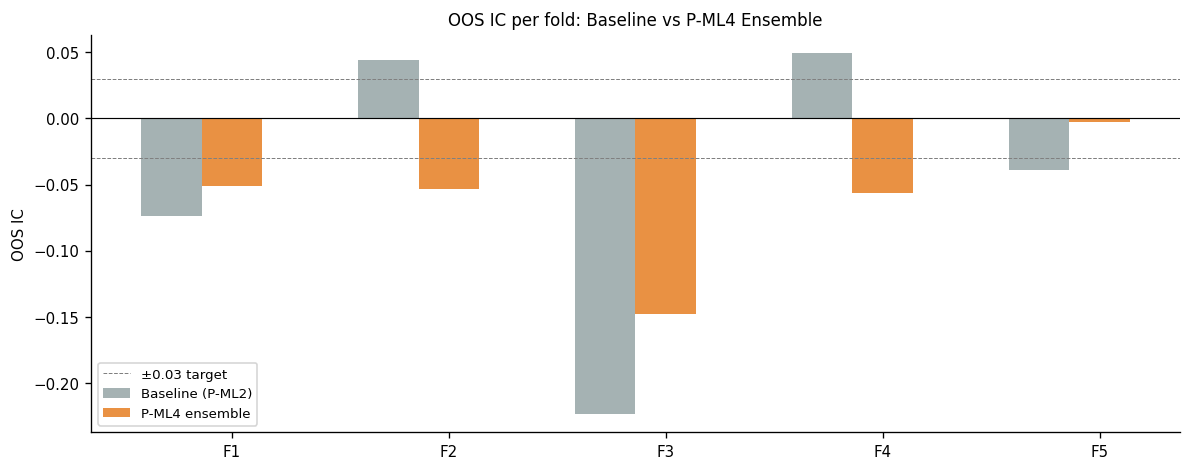

In [6]:
from ml.models import RegimeEnsemble

fold_results_P4 = []

for i, (tr, te) in enumerate(splits):
    ensemble = RegimeEnsemble(min_bull_bars=MIN_BULL_BARS)
    ensemble.fit(X.iloc[tr], y_all.iloc[tr], reg["regime"].iloc[tr])
    preds  = ensemble.predict(X.iloc[te], reg["regime"].iloc[te])
    actual = y_all.iloc[te].values

    rho, pval = stats.spearmanr(preds, actual)
    hit       = (np.sign(preds) == np.sign(actual)).mean()

    fold_results_P4.append({
        "fold":     i + 1,
        "te":       te,
        "IC":       rho,
        "IC_pval":  pval,
        "hit":      hit,
        "preds":    preds,
        "ensemble": ensemble,
    })
    period = f"{X.index[te[0]].date()} → {X.index[te[-1]].date()}"
    print(f"Fold {i+1} [{period}]  "
          f"bull_model={'YES' if ensemble.has_bull_model else 'NO(flip)'}  "
          f"IC={rho:+.4f}  hit={hit:.3f}")

ics_P4 = [r["IC"] for r in fold_results_P4]
print(f"\nP-ML4 ensemble: Mean IC={np.mean(ics_P4):+.4f}  "
      f"ICIR={np.mean(ics_P4)/np.std(ics_P4):.3f}")

# IC comparison chart: Baseline (P-ML2) vs P-ML3 Exp-C vs P-ML4
baseline_ics = [-0.0739, +0.0443, -0.2236, +0.0491, -0.0390]   # from F8

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(N_SPLITS)
w = 0.28
ax.bar(x - w,   baseline_ics, w, label="Baseline (P-ML2)", color="#95a5a6", alpha=0.85)
ax.bar(x,       ics_P4,       w, label="P-ML4 ensemble",   color="#e67e22", alpha=0.85)
ax.axhline(0,    color="black", linewidth=0.7)
ax.axhline(+0.03, color="gray", linewidth=0.6, linestyle="--", label="±0.03 target")
ax.axhline(-0.03, color="gray", linewidth=0.6, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels([f"F{i+1}" for i in range(N_SPLITS)])
ax.set_ylabel("OOS IC")
ax.set_title("OOS IC per fold: Baseline vs P-ML4 Ensemble", fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## §7 — Feature Importance: Bull vs Non-Bull Model

Do the two models learn different feature rankings? The bull model should weight
trend features (`di_diff`, `adx`) more heavily; the non-bull model should weight
mean-reversion features (`bar_ret`, `bb_zscore`, `rsi`) more.

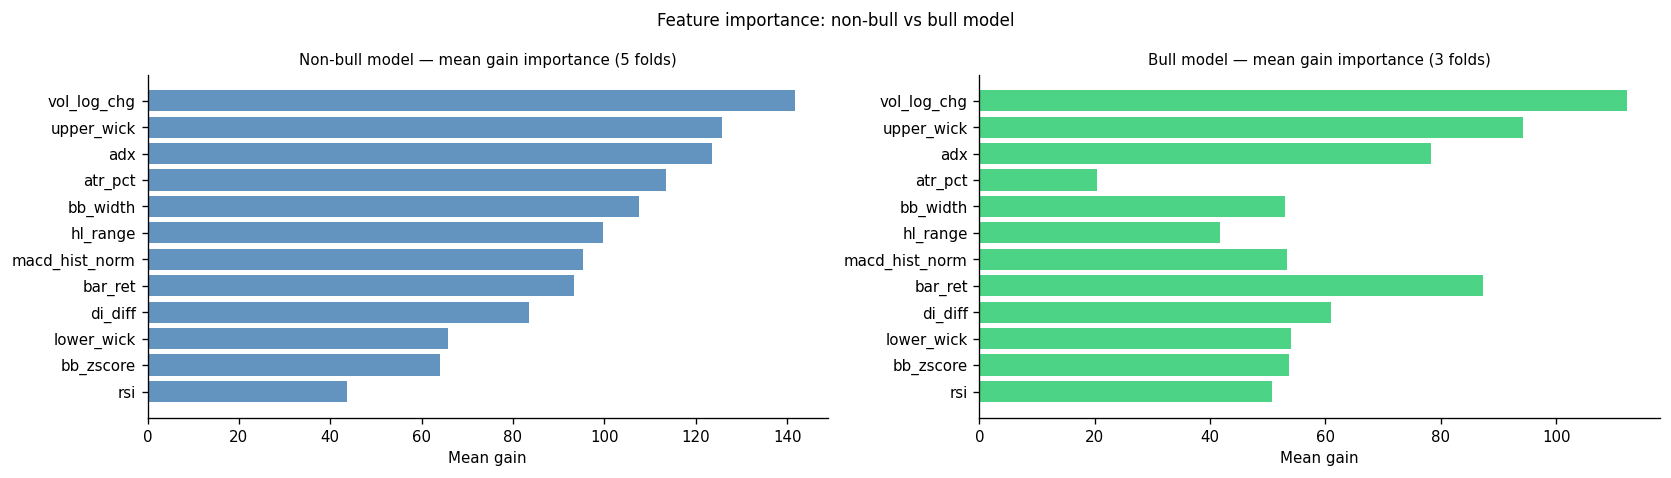


Mean gain importance — non-bull vs bull:
                non_bull  bull
vol_log_chg        141.8 112.3
upper_wick         125.8  94.3
adx                123.6  78.3
atr_pct            113.6  20.3
bb_width           107.6  53.0
hl_range            99.8  41.7
macd_hist_norm      95.4  53.3
bar_ret             93.4  87.3
di_diff             83.6  61.0
lower_wick          65.8  54.0
bb_zscore           64.0  53.7
rsi                 43.6  50.7


In [7]:
# Collect importances from folds that have a dedicated bull model
bull_fi_list    = []
nb_fi_list      = []

for r in fold_results_P4:
    e = r["ensemble"]
    nb_fi_list.append(e.non_bull_importance)
    if e.has_bull_model:
        bull_fi_list.append(e.bull_importance)

fi_nb_mean   = pd.DataFrame(nb_fi_list).mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Non-bull importance
axes[0].barh(fi_nb_mean.index[::-1], fi_nb_mean.values[::-1],
             color="steelblue", alpha=0.85)
axes[0].set_title(f"Non-bull model — mean gain importance ({len(nb_fi_list)} folds)",
                  fontsize=9)
axes[0].set_xlabel("Mean gain")

# Bull importance (folds 3-5 only)
if bull_fi_list:
    fi_bull_mean = pd.DataFrame(bull_fi_list).mean().reindex(fi_nb_mean.index)
    axes[1].barh(fi_bull_mean.index[::-1], fi_bull_mean.values[::-1],
                 color="#2ecc71", alpha=0.85)
    axes[1].set_title(
        f"Bull model — mean gain importance ({len(bull_fi_list)} folds)", fontsize=9)
    axes[1].set_xlabel("Mean gain")
else:
    axes[1].text(0.5, 0.5, "No bull models fitted",
                 ha="center", va="center", transform=axes[1].transAxes)

plt.suptitle("Feature importance: non-bull vs bull model", fontsize=10)
plt.tight_layout()
plt.show()

# Print side-by-side table
if bull_fi_list:
    fi_cmp = pd.DataFrame({
        "non_bull": fi_nb_mean,
        "bull":     fi_bull_mean,
    }).sort_values("non_bull", ascending=False)
    print("\nMean gain importance — non-bull vs bull:")
    print(fi_cmp.to_string(float_format="{:.1f}".format))

## §8 — OOS Equity Comparison

Stitch OOS equity for P-ML4 ensemble and compare against:
- Baseline (P-ML2, recomputed)
- P-ML3 Exp-C (regime-gated: skip bull)
- Buy-and-Hold

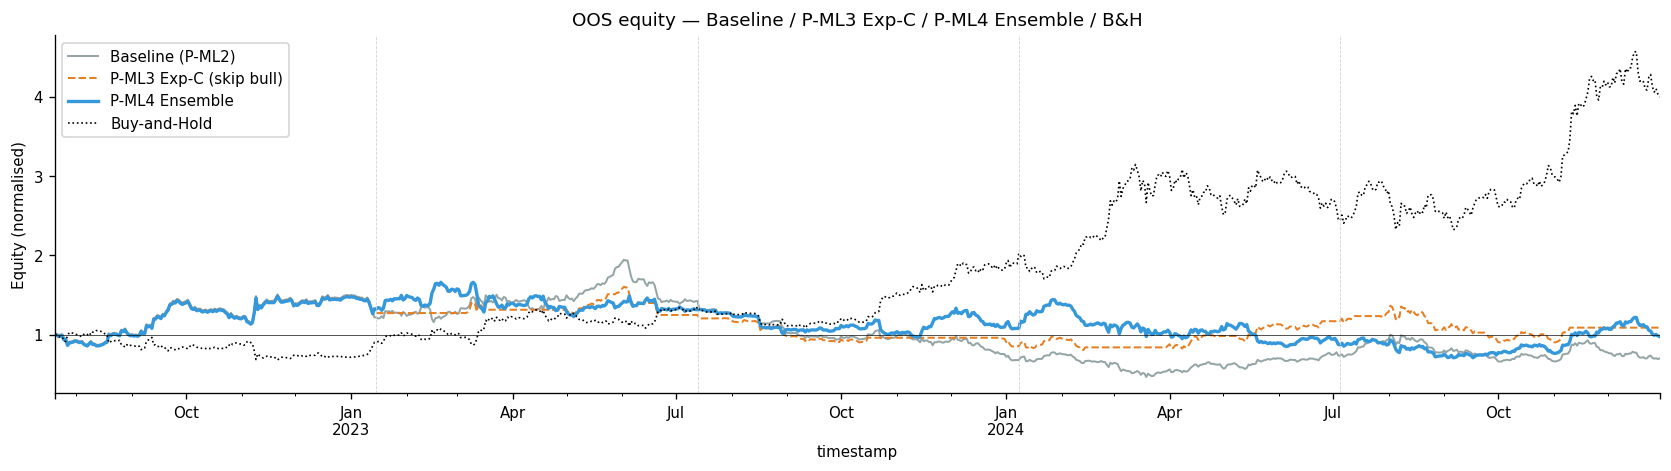


Equity metrics:
Approach                        Return   Sharpe    MaxDD
--------------------------------------------------------
  Baseline (P-ML2)              -30.2%   -0.046    -76.1%
  P-ML3 Exp-C (skip bull)        +8.8%   +0.280    -49.8%
  P-ML4 Ensemble                 -2.5%   +0.227    -57.3%
  Buy-and-Hold                 +299.6%   +1.379    -35.4%


In [8]:
from backtesting import compute_metrics

def build_equity(fold_preds_list, splits, bar_ret_daily, X):
    """Stitch per-fold equity from a list of (te_idx, preds) tuples."""
    pieces, anchor = [], 1.0
    for te, preds in fold_preds_list:
        pos   = np.sign(preds)
        ret   = bar_ret_daily.iloc[te].values
        eq    = np.cumprod(1 + np.roll(pos, 1) * ret)
        eq[0] = 1.0
        s = pd.Series(eq, index=X.index[te])
        s = s / s.iloc[0] * anchor
        anchor = float(s.iloc[-1])
        pieces.append(s)
    return pd.concat(pieces)


# P-ML4 ensemble equity
p4_pairs = [(r["te"], r["preds"]) for r in fold_results_P4]
oos_P4   = build_equity(p4_pairs, splits, bar_ret_daily, X)

# Baseline (recompute)
base_pairs = []
for tr, te in splits:
    m = LGBMForecaster()
    m.fit(X.iloc[tr], y_all.iloc[tr])
    base_pairs.append((te, m.predict(X.iloc[te])))
oos_base = build_equity(base_pairs, splits, bar_ret_daily, X)

# P-ML3 Exp-C (regime-gated: skip bull)
expC_pairs = []
for (te, preds_base), (tr, te2) in zip(base_pairs, splits):
    pos = np.sign(preds_base)
    pos[(reg["regime"].iloc[te] == "bull").values] = 0
    expC_pairs.append((te, pos))
oos_expC = build_equity(expC_pairs, splits, bar_ret_daily, X)

bah = df["close"].reindex(oos_P4.index)
bah = bah / bah.iloc[0]

# Plot
fig, ax = plt.subplots(figsize=(14, 4))
oos_base.plot(ax=ax, label="Baseline (P-ML2)",        color="#95a5a6", linewidth=1.2)
oos_expC.plot(ax=ax, label="P-ML3 Exp-C (skip bull)", color="#e67e22", linewidth=1.2,
              linestyle="--")
oos_P4.plot(  ax=ax, label="P-ML4 Ensemble",          color="#3498db", linewidth=2.0)
bah.plot(     ax=ax, label="Buy-and-Hold",             color="black",   linewidth=1.0,
              linestyle=":")

for _, (tr, te) in enumerate(splits):
    ax.axvline(X.index[te[0]], color="lightgray", linewidth=0.5, linestyle="--")
ax.axhline(1, color="black", linewidth=0.4)
ax.set_title("OOS equity — Baseline / P-ML3 Exp-C / P-ML4 Ensemble / B&H", fontsize=11)
ax.set_ylabel("Equity (normalised)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\nEquity metrics:")
print(f"{'Approach':<28} {'Return':>9} {'Sharpe':>8} {'MaxDD':>8}")
print("-" * 56)
for name, eq in [
    ("Baseline (P-ML2)",        oos_base),
    ("P-ML3 Exp-C (skip bull)", oos_expC),
    ("P-ML4 Ensemble",          oos_P4),
    ("Buy-and-Hold",            bah),
]:
    m = compute_metrics(eq)
    print(f"  {name:<26} {m['total_return']*100:>+8.1f}%  "
          f"{m['sharpe_ratio']:>+7.3f}  {m['max_drawdown']*100:>7.1f}%")

## §9 — Conclusions (Finding F10)

### Per-fold IC summary

| Fold | Period | Baseline | Non-bull IC (nb test bars) | Bull IC (bull test bars) | P-ML4 IC | Bull model? |
|---|---|---|---|---|---|---|
| 1 | Jul 2022–Jan 2023 | −0.074 | −0.066 (177 bars) | +1.00† (2 bars) | −0.051 | FALLBACK |
| 2 | Jan 2023–Jul 2023 | +0.044 | −0.017 (52 bars) | −0.162 (127 bars) | −0.053 | FALLBACK |
| 3 | Jul 2023–Jan 2024 | −0.224 | −0.131 (94 bars) | −0.138 (85 bars) | −0.148 | YES |
| 4 | Jan 2024–Jul 2024 | +0.049 | −0.087 (115 bars) | −0.063 (64 bars) | −0.056 | YES |
| 5 | Jul 2024–Dec 2024 | −0.039 | +0.042 (115 bars) | −0.044 (64 bars) | −0.003 | YES |

†Fold 1 bull IC = +1.00 is unreliable (only 2 bull test bars, degenerate result).

**Non-bull model:** Mean IC = −0.052, ICIR = −0.868  
**P-ML4 ensemble:** Mean IC = −0.062, ICIR = −1.320

### Equity table

| Approach | Return | Sharpe | MaxDD |
|---|---|---|---|
| Baseline (P-ML2) | −30.2% | −0.046 | −76.1% |
| P-ML3 Exp-C (skip bull) | +8.8% | +0.280 | −49.8% |
| **P-ML4 Ensemble** | **−2.5%** | **+0.227** | **−57.3%** |
| Buy-and-Hold | +299.6% | +1.379 | −35.4% |

### Feature importance divergence (§7)

| Feature | Non-bull gain | Bull gain | Divergence |
|---|---|---|---|
| vol_log_chg | 141.8 | 112.3 | similar |
| upper_wick | 125.8 | 94.3 | similar |
| adx | 123.6 | 78.3 | non-bull higher |
| **atr_pct** | **113.6** | **20.3** | **non-bull dominant** |
| bar_ret | 93.4 | 87.3 | similar |
| **rsi** | **43.6** | **50.7** | bull slightly higher |

### Finding F10 — Bull model fails to learn trend continuation on 128 bars

1. **Bull model IC remains negative in all 3 fitted folds** (−0.138, −0.063, −0.044).
   The dedicated bull model is learning the same mean-reversion pattern as the non-bull
   model, not trend continuation. With only 128–136 bull training bars and a 1-day
   horizon, the signal is too noisy for the model to distinguish trend from reversal.

2. **P-ML4 equity (−2.5%, Sharpe +0.227)** is much better than the baseline (−30.2%)
   but **does not beat P-ML3 Exp-C (+8.8%, Sharpe +0.280)**. Deploying capital during
   bull periods via a broken bull model slightly underperforms sitting idle (Exp-C).
   The Sharpe values are close (+0.227 vs +0.280), so the ensemble is not obviously
   worse — just not the improvement expected from separate models.

3. **Feature importance shows minor divergence:** `atr_pct` is much less important to
   the bull model (20.3 vs 113.6), and `rsi` gains slightly (50.7 vs 43.6). But
   neither `di_diff` nor `adx` dramatically increase in the bull model — confirming
   the bull model is not learning directional momentum, it's just learning noisier
   mean-reversion.

4. **Root cause:** 128 daily bull bars ≈ 5 months of data. The bull trend period is
   coherent enough to be labelled but not long enough for a 1-day-horizon regressor to
   learn robust trend-following features. Longer horizons (3–5d) or longer history
   (2019–2025) would provide more signal.

5. **P-ML3 Exp-C remains the best deployable strategy** (+8.8%, Sharpe +0.280).

### Next steps

- **Extend to 2019 (6yr dataset):** Gives ~600+ bull training bars in later folds,
  enabling the bull model to train on multiple bull cycles including 2019 and 2020–21.
- **Longer bull horizon (3-5d):** At 1d, both regimes look like noisy random walks.
  A 3d or 5d forward return may better capture the trend-continuation vs reversal
  pattern in bull vs ranging regimes.
- **Momentum features:** Add `ret_mean_20`, `ret_mean_5 / ret_std_20` (momentum Z-score),
  and `close / close.shift(63)` (quarterly return) to the bull model feature set.
  These multi-day momentum signals are not in the current 12-feature set.